In [23]:
import numpy as np
import matplotlib.pyplot as plt 
from prettytable import PrettyTable

In [24]:
def least_square_fitting(X, Y,X_axis,Y_axis,plot,params):
    # TABLE DATA
    Σx2 = 0
    Σy = 0
    Σxy = 0
    Σx = 0
    count = 0
    Σxylist = []
    Σx2list = []
    Slno = [ ]

    for i in range(len(X)):
        Σx2 += X[i]**2
        Σx2list.append(round(X[i]**2,4))
        Σy += Y[i]
        Σxy += X[i]*Y[i]
        Σxylist.append(round(X[i]*Y[i],4))
        Σx += X[i]
        count += 1
        Slno.append(count)
    # Finding slope and intercept
    fit = np.polyfit(X,Y,1)
    A = fit[0]
    B = fit[1]
    def f(x):
      return A*x + B
    # Error analysis
    error_sum = 0
    for i in range(len(X)):
        error_sum += (Y[i] - f(X[i]))**2
    error_y = (error_sum/ (len(X) - 2))**0.5
    delta = len(X)*Σx2 - Σx**2
    error_slope = error_y * (len(X)/delta)**0.5
    error_intercept = error_y * (Σx2/delta)**0.5
    if params==True:
        #Printing slopes,intercepts and errors
        table2 = PrettyTable()
        table2.title = "Slope, Intercept and Errors"
        table2.add_row(["Slope" , round(A,3) ])
        table2.add_row(["Intercept" , round(B,3) ])
        table2.add_row(["Error in y", round(error_y,3) ])
        table2.add_row(["Delta" , round(delta,5) ])
        table2.add_row(["Error in slope", round(error_slope,5) ])
        table2.add_row(["Error in intercept", round(error_intercept,5) ])
        print(table2)
        print()

    if plot==True:
        #GRAPH PLOT
        plt.xlabel(X_axis)
        plt.ylabel(Y_axis)
        plt.title(X_axis + " vs " + Y_axis)
        plt.grid()
        plt.scatter(X,Y,label='Data Points',s=20,c='darkblue')
        fit = np.polyfit(X,Y,1)
        x_fit = np.linspace(min(X),max(X),1000)
        y_fit = fit[1]+fit[0]*x_fit

         # display table(least square fitting)
        X_r = [round(x,4) for x in X]
        Y_r = [round(y,4) for y in Y]
        delta_Y = [round(Y[i] - f(X[i]),4) for i in range(len(X))]
        table = PrettyTable()
        table.field_names = ["Sl No.","X", "Y", "X^2", "XY","Delta Y"]
        table.add_rows(list(zip(Slno, X_r, Y_r, Σx2list, Σxylist, delta_Y)))
        table.add_row([" ",'','','','',''])
        table.add_row(["Total -", round(Σx,4), round(Σy,4), round(Σx2,4), round(Σxy,4), ""])
        print(table)
        plt.plot(x_fit,y_fit,'--', color='r',label = f'Least-square fit line : y = ({round(A,3)}±{round(error_slope,3)})x + ({round(B,3)}±{round(error_intercept,3)})')
        plt.legend()
        plt.show()


Gain:  [6.27027027027027, 19.243243243243242, 49.729729729729726, 66.48648648648648, 87.56756756756756, 140.54054054054055, 187.02702702702703, 250.8108108108108, 326.48648648648646, 404.3243243243243]
Log(Gain):  [0.79728626 1.28427827 1.6966161  1.82273338 1.94234329 2.14780162
 2.27190437 2.39934625 2.51386521 2.60672987]
Log(Va):  [-0.52287875 -0.45593196 -0.39794001 -0.34678749 -0.30103    -0.25963731
 -0.22184875 -0.18708664 -0.15490196 -0.12493874]
+------------------------------+
| Slope, Intercept and Errors  |
+--------------------+---------+
|      Field 1       | Field 2 |
+--------------------+---------+
|       Slope        |  4.258  |
|     Intercept      |  3.214  |
|     Error in y     |  0.103  |
|       Delta        | 1.57885 |
|   Error in slope   |  0.2583 |
| Error in intercept | 0.08337 |
+--------------------+---------+

+---------+---------+---------+--------+---------+---------+
|  Sl No. |    X    |    Y    |  X^2   |    XY   | Delta Y |
+---------+---------+

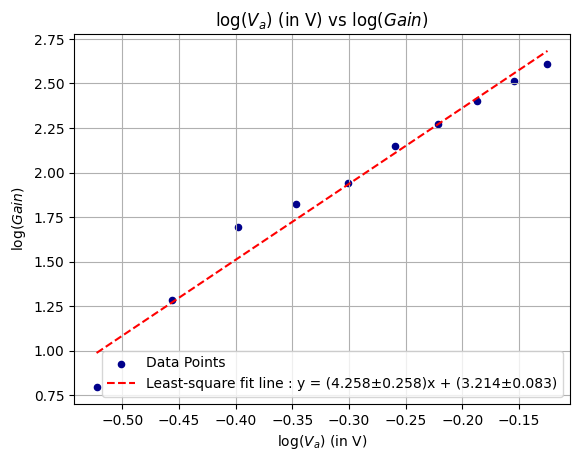

In [25]:
# PMT 
#current gain
lambda_red = 635 #nm  
Vin_pmt = 0.185 # input voltage in V
Va_pmt = [0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75] # applied voltage in V
Vo_pmt = [1.16,3.56,9.2,12.3,16.2,26.0,34.6,46.4,60.4,74.8] # output voltage in V

gain = [p/Vin_pmt for p in Vo_pmt] 
log_g = np.log10(gain)
log_Va = np.log10(Va_pmt)

print("Gain: ", gain)
print("Log(Gain): ", log_g)
print("Log(Va): ", log_Va)

#plot 
least_square_fitting(log_Va,log_g,r'$\log(V_a)$ (in V)',r'$\log(Gain)$',True,True)

[0.2, 0.3, 0.5, 0.7, 0.9, 1.1, 1.1, 1.4, 2.1, 3.3]


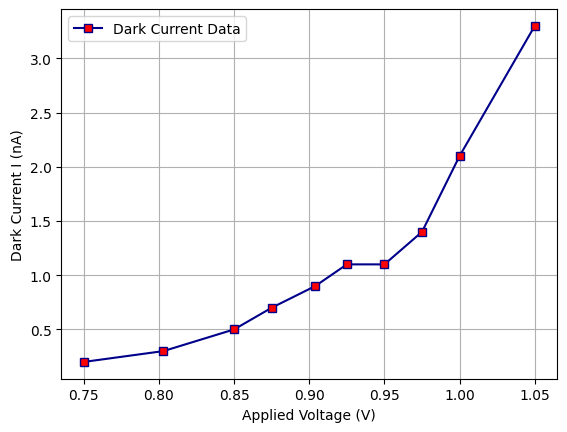

In [26]:
# Dark current data
V_a = [0.75,0.803,0.85,0.875,0.904,0.925,0.95,0.975,1,1.05] # in V
Vo_pmt = [0.002,0.003,0.005,0.007,0.009,0.011,0.011,0.014,0.021,0.033] # in V
I_pmt = [round(v*100,3) for v in Vo_pmt] # in nA (multimeter impedence is 10 Mohm)
print(I_pmt)

plt.plot(V_a,I_pmt,marker='s',mfc='r',color='darkblue',label='Dark Current Data')
plt.xlabel('Applied Voltage (V)')
plt.ylabel('Dark Current I (nA)')
plt.legend()
plt.grid()
plt.show()

[0.0186, 0.0188, 0.0188, 0.0186, 0.0187] 
 [12.2, 10.4, 9.6, 9.6, 9.2] 
 [655.914, 553.191, 510.638, 516.129, 491.979]


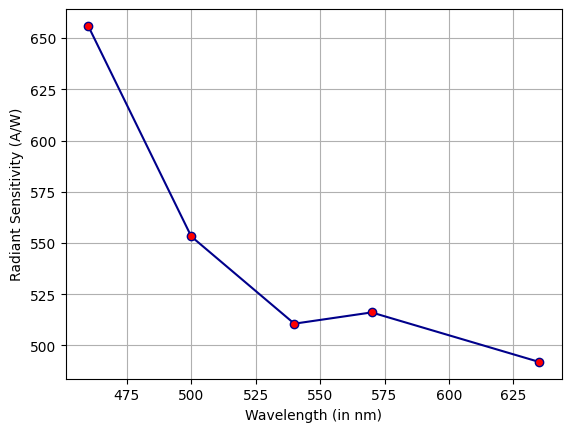

In [ ]:
# spectral response
wavelength = [460,500,540,570,635] # using diff filters (in nm)
# source 
Vs = [1.62,1.41,1.218,1.221,1.213] # in V
Is = [292.2,272.4,254.4,254.3,253.5] # in mV
# photo detector
Vp = [0.186,0.188,0.188,0.186,0.187] # in V
Ip = [0.1,0.1,0.1,0.1,0.1] # in uA
Pp = [round(v*i,5) for i,v in zip(Ip,Vp)] # in uW
# PMT
Vpmt = [12.2,10.4,9.6,9.6,9.2] # in V
Ipmt = [v for v in Vpmt] # in uA (as DSO impedence is 1Mohm)

sensitivity = [round(Ipmt[i]/Pp[i],3) for i in range(len(Ipmt))] # radian sensitivity (A/W)
print(Pp,'\n',Ipmt,'\n',sensitivity) 


plt.plot(wavelength,sensitivity,marker='o',mfc='r',color='darkblue')
plt.xlabel('Wavelength (in nm)')
plt.ylabel('Radiant Sensitivity (A/W)')
plt.grid()
plt.show()
